<a href="https://colab.research.google.com/github/yuva0567890/23MID0421APAassignment4/blob/main/APA4DATASET1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas numpy scikit-learn matplotlib joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn

from pathlib import Path
from joblib import dump

In [3]:
SEED = 42
np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [4]:
OUT = Path("lab04_outputs")

for folder in ["figures", "models", "artifacts", "results"]:
    (OUT / folder).mkdir(parents=True, exist_ok=True)

print("Output folders created")

Output folders created


In [5]:
import sys
import platform

versions = {
    "python": sys.version,
    "platform": platform.platform(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__
}

print(versions)

{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35', 'pandas': '2.2.2', 'numpy': '2.0.2', 'scikit_learn': '1.6.1'}


In [6]:
# Dataset 1: JanataHack Customer Segmentation - Train.csv

import pandas as pd

df = pd.read_csv("/content/Train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (8068, 11)


In [7]:
# Dataset 1: Basic Dataset Inspection


print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB

Missing Values:
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_S

In [8]:
# Check dataset structure, columns, data types, and missing values
print(df.head())
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df['Segmentation'].value_counts())

       ID  Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
0  462809    Male           No   22        No     Healthcare              1.0   
1  462643  Female          Yes   38       Yes       Engineer              NaN   
2  466315  Female          Yes   67       Yes       Engineer              1.0   
3  461735    Male          Yes   67       Yes         Lawyer              0.0   
4  462669  Female          Yes   40       Yes  Entertainment              NaN   

  Spending_Score  Family_Size  Var_1 Segmentation  
0            Low          4.0  Cat_4            D  
1        Average          3.0  Cat_4            A  
2            Low          1.0  Cat_6            B  
3           High          2.0  Cat_6            B  
4           High          6.0  Cat_6            A  
(8068, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           -------------- 

In [9]:
# Handle missing values, remove duplicates, and exclude the customer ID
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

df = df.drop(columns=['ID'])

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in df.select_dtypes(exclude='object').columns:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:")
print(df.isnull().sum().sum())

print("New shape:", df.shape)

Duplicate rows: 0
Remaining missing values:
0
New shape: (8068, 10)


In [10]:
# Separate input features from the target variable
X = df.drop(columns=['Segmentation'])
y = df['Segmentation']

In [11]:
# Check customer segment distribution
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Segmentation
D    2268
A    1972
C    1970
B    1858
Name: count, dtype: int64
Segmentation
D    28.111056
A    24.442241
C    24.417452
B    23.029251
Name: proportion, dtype: float64


In [12]:
# Create a stratified train-test split while keeping the test set untouched
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [13]:
# Separate numerical and categorical features for model-specific preprocessing
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['Age', 'Work_Experience', 'Family_Size']
Categorical: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


In [14]:
# Separate numerical and categorical features
num_cols = ['Age', 'Work_Experience', 'Family_Size']
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

print("Numerical features:", num_cols)
print("Categorical features:", cat_cols)

Numerical features: ['Age', 'Work_Experience', 'Family_Size']
Categorical features: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


In [15]:
# Split the dataset into training and testing data
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Segmentation'])
y = df['Segmentation']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [45]:
# Train a simple baseline model using the most frequent customer segment
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Dummy Macro F1:", f1_score(y_test, y_pred_dummy, average='macro'))

Dummy Accuracy: 0.2812887236679058
Dummy Macro F1: 0.10976789168278529


In [16]:
# Prepare numerical features for Gaussian Naive Bayes
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')

X_train_num = imputer.fit_transform(X_train[num_cols])
X_test_num = imputer.transform(X_test[num_cols])

scaler = StandardScaler()

X_train_gaussian = scaler.fit_transform(X_train_num)
X_test_gaussian = scaler.transform(X_test_num)

In [17]:
# Train the Gaussian Naive Bayes classifier
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train_gaussian, y_train)

y_pred_gnb = gnb.predict(X_test_gaussian)

In [18]:
# Evaluate GaussianNB using accuracy and macro F1
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("GaussianNB Macro F1:", f1_score(y_test, y_pred_gnb, average='macro'))
print(classification_report(y_test, y_pred_gnb))

GaussianNB Accuracy: 0.4163568773234201
GaussianNB Macro F1: 0.36446473732016466
              precision    recall  f1-score   support

           A       0.38      0.20      0.26       394
           B       0.30      0.13      0.18       372
           C       0.37      0.50      0.43       394
           D       0.49      0.77      0.60       454

    accuracy                           0.42      1614
   macro avg       0.38      0.40      0.36      1614
weighted avg       0.39      0.42      0.38      1614



In [47]:
# Evaluate GaussianNB using 5-fold stratified cross validation
from sklearn.metrics import f1_score
import numpy as np

gnb_scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    X_tr_num = imputer.fit_transform(X_tr[num_cols])
    X_val_num = imputer.transform(X_val[num_cols])

    X_tr_num = scaler.fit_transform(X_tr_num)
    X_val_num = scaler.transform(X_val_num)

    model = GaussianNB()
    model.fit(X_tr_num, y_tr)

    pred = model.predict(X_val_num)

    gnb_scores.append(f1_score(y_val, pred, average='macro'))

print("GaussianNB Fold Scores:", gnb_scores)
print("GaussianNB Mean F1:", np.mean(gnb_scores))
print("GaussianNB SD:", np.std(gnb_scores))

GaussianNB Fold Scores: [0.3786134474910343, 0.3677498950598864, 0.3761638108418617, 0.36856844942789724, 0.3736629173138568]
GaussianNB Mean F1: 0.3729517040269073
GaussianNB SD: 0.0042225710412713375


In [19]:
# Convert categorical features into non-negative integer codes for CategoricalNB
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

X_train_cat = X_train_cat + 1
X_test_cat = X_test_cat + 1

In [20]:
# Train the Categorical Naive Bayes classifier
from sklearn.naive_bayes import CategoricalNB

cnb = CategoricalNB(alpha=1.0)
cnb.fit(X_train_cat, y_train)

y_pred_cnb = cnb.predict(X_test_cat)

In [49]:
# Evaluate CategoricalNB using the same 5-fold stratified cross validation
cnb_scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    encoder_cv = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )

    X_tr_cat = encoder_cv.fit_transform(X_tr[cat_cols])
    X_val_cat = encoder_cv.transform(X_val[cat_cols])

    X_tr_cat = X_tr_cat + 1
    X_val_cat = X_val_cat + 1

    model = CategoricalNB()
    model.fit(X_tr_cat, y_tr)

    pred = model.predict(X_val_cat)

    cnb_scores.append(f1_score(y_val, pred, average='macro'))

print("CategoricalNB Fold Scores:", cnb_scores)
print("CategoricalNB Mean F1:", np.mean(cnb_scores))
print("CategoricalNB SD:", np.std(cnb_scores))

CategoricalNB Fold Scores: [0.4592300718768858, 0.4652367580501705, 0.47085091890625413, 0.46300929116109224, 0.4759030081927686]
CategoricalNB Mean F1: 0.46684600963743417
CategoricalNB SD: 0.005888652280329865


In [21]:
# Evaluate CategoricalNB using accuracy and macro F1
print("CategoricalNB Accuracy:", accuracy_score(y_test, y_pred_cnb))
print("CategoricalNB Macro F1:", f1_score(y_test, y_pred_cnb, average='macro'))
print(classification_report(y_test, y_pred_cnb))

CategoricalNB Accuracy: 0.5136307311028501
CategoricalNB Macro F1: 0.48532268407244467
              precision    recall  f1-score   support

           A       0.41      0.45      0.43       394
           B       0.42      0.20      0.27       372
           C       0.50      0.63      0.56       394
           D       0.65      0.73      0.68       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.49      1614
weighted avg       0.50      0.51      0.50      1614



In [22]:
# Convert categorical features into binary 0/1 features for BernoulliNB
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

bernoulli_preprocessor = ColumnTransformer([
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

X_train_bern = bernoulli_preprocessor.fit_transform(X_train)
X_test_bern = bernoulli_preprocessor.transform(X_test)

print("Bernoulli input shape:", X_train_bern.shape)

Bernoulli input shape: (6454, 25)


In [23]:
# Train the Bernoulli Naive Bayes classifier
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()
bnb.fit(X_train_bern, y_train)

y_pred_bnb = bnb.predict(X_test_bern)

In [50]:
# Evaluate BernoulliNB using the same 5-fold stratified cross validation
bnb_scores = []

for train_idx, val_idx in skf.split(X, y):
    X_tr = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    X_tr_bern = bernoulli_preprocessor.fit_transform(X_tr)
    X_val_bern = bernoulli_preprocessor.transform(X_val)

    model = BernoulliNB()
    model.fit(X_tr_bern, y_tr)

    pred = model.predict(X_val_bern)

    bnb_scores.append(f1_score(y_val, pred, average='macro'))

print("BernoulliNB Fold Scores:", bnb_scores)
print("BernoulliNB Mean F1:", np.mean(bnb_scores))
print("BernoulliNB SD:", np.std(bnb_scores))

BernoulliNB Fold Scores: [0.459074868719796, 0.46686408090774595, 0.4768074995435999, 0.46167739232450183, 0.47993715676142934]
BernoulliNB Mean F1: 0.4688721996514146
BernoulliNB SD: 0.008212036860232703


In [46]:
# Create the same 5 stratified folds for all models
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold Cross Validation created successfully")

5-Fold Cross Validation created successfully


In [51]:
# Create a comparison table for cross-validation performance
cv_results = pd.DataFrame({
    'Model': ['GaussianNB', 'CategoricalNB', 'BernoulliNB'],
    'Fold 1': [gnb_scores[0], cnb_scores[0], bnb_scores[0]],
    'Fold 2': [gnb_scores[1], cnb_scores[1], bnb_scores[1]],
    'Fold 3': [gnb_scores[2], cnb_scores[2], bnb_scores[2]],
    'Fold 4': [gnb_scores[3], cnb_scores[3], bnb_scores[3]],
    'Fold 5': [gnb_scores[4], cnb_scores[4], bnb_scores[4]],
    'Mean Macro F1': [
        np.mean(gnb_scores),
        np.mean(cnb_scores),
        np.mean(bnb_scores)
    ],
    'SD': [
        np.std(gnb_scores),
        np.std(cnb_scores),
        np.std(bnb_scores)
    ]
})

display(cv_results)

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Macro F1,SD
0,GaussianNB,0.378613,0.367750,0.376164,0.368568,0.373663,0.372952,0.004223
1,CategoricalNB,0.459230,0.465237,0.470851,0.463009,0.475903,0.466846,0.005889
2,BernoulliNB,0.459075,0.466864,0.476807,0.461677,0.479937,0.468872,0.008212


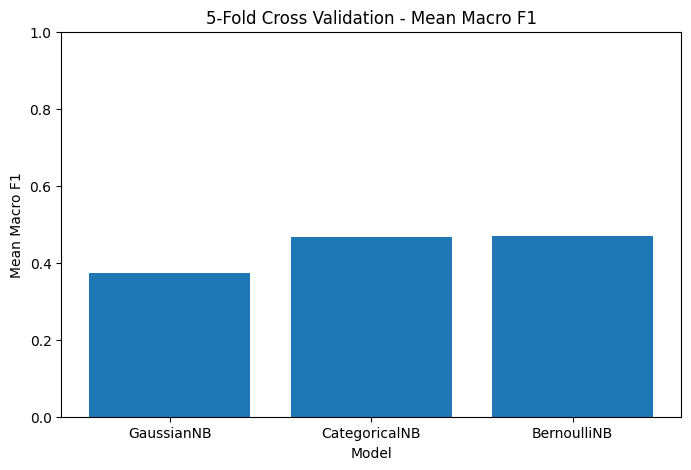

In [52]:
# Visualize mean macro F1 from cross validation
plt.figure(figsize=(8,5))

plt.bar(cv_results['Model'], cv_results['Mean Macro F1'])

plt.title('5-Fold Cross Validation - Mean Macro F1')
plt.xlabel('Model')
plt.ylabel('Mean Macro F1')
plt.ylim(0,1)

plt.show()

In [24]:
# Evaluate BernoulliNB using accuracy and macro F1
print("BernoulliNB Accuracy:", accuracy_score(y_test, y_pred_bnb))
print("BernoulliNB Macro F1:", f1_score(y_test, y_pred_bnb, average='macro'))
print(classification_report(y_test, y_pred_bnb))

BernoulliNB Accuracy: 0.5024783147459727
BernoulliNB Macro F1: 0.47271257348381146
              precision    recall  f1-score   support

           A       0.41      0.39      0.40       394
           B       0.37      0.20      0.26       372
           C       0.49      0.64      0.56       394
           D       0.63      0.73      0.67       454

    accuracy                           0.50      1614
   macro avg       0.48      0.49      0.47      1614
weighted avg       0.48      0.50      0.48      1614



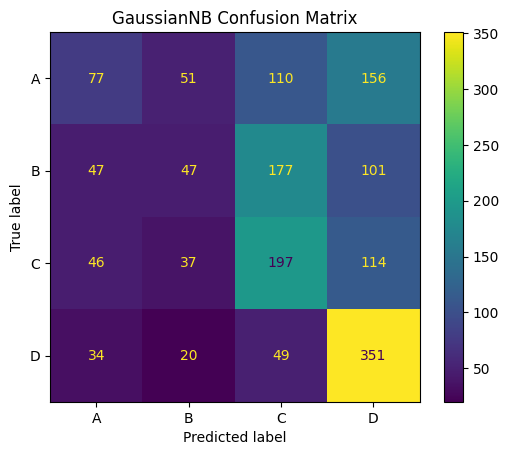

In [25]:
# Confusion matrix for GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gnb)

plt.title('GaussianNB Confusion Matrix')
plt.show()

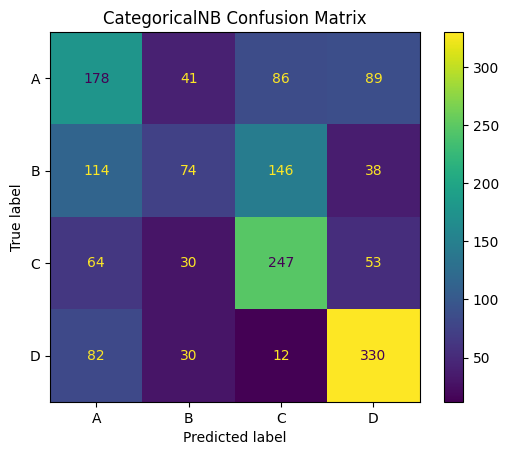

In [26]:
# Confusion matrix for CategoricalNB
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cnb)

plt.title('CategoricalNB Confusion Matrix')
plt.show()

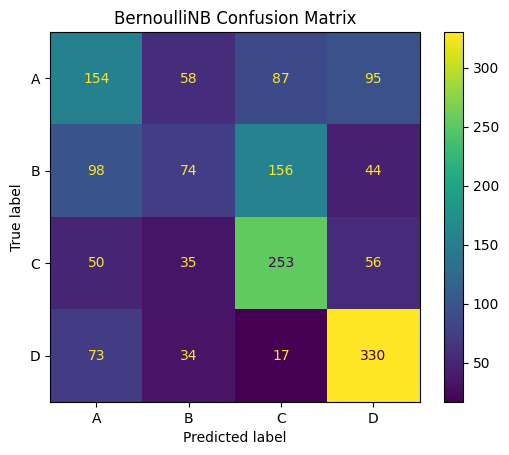

In [27]:
# Confusion matrix for BernoulliNB
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bnb)

plt.title('BernoulliNB Confusion Matrix')
plt.show()

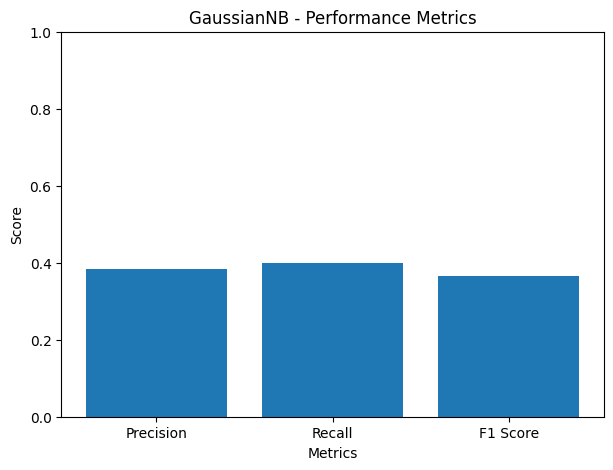

In [28]:
# Visualize Precision, Recall, and F1-score for GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision = precision_score(y_test, y_pred_gnb, average='macro')
recall = recall_score(y_test, y_pred_gnb, average='macro')
f1 = f1_score(y_test, y_pred_gnb, average='macro')

metrics = ['Precision', 'Recall', 'F1 Score']
values = [precision, recall, f1]

plt.figure(figsize=(7,5))
plt.bar(metrics, values)
plt.title('GaussianNB - Performance Metrics')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.show()

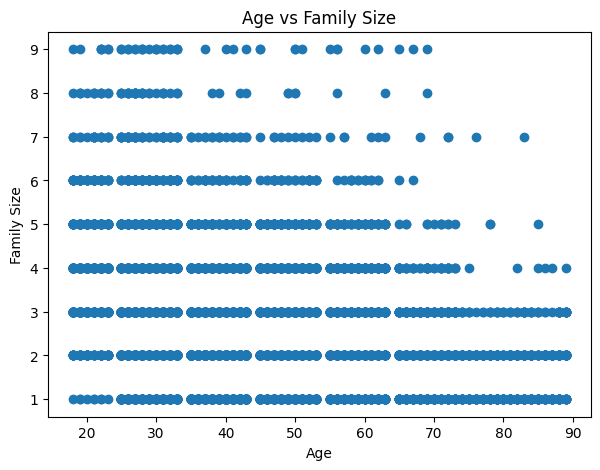

In [29]:
# Plot the relationship between age and family size
plt.figure(figsize=(7,5))
plt.scatter(df['Age'], df['Family_Size'])
plt.title('Age vs Family Size')
plt.xlabel('Age')
plt.ylabel('Family Size')
plt.show()

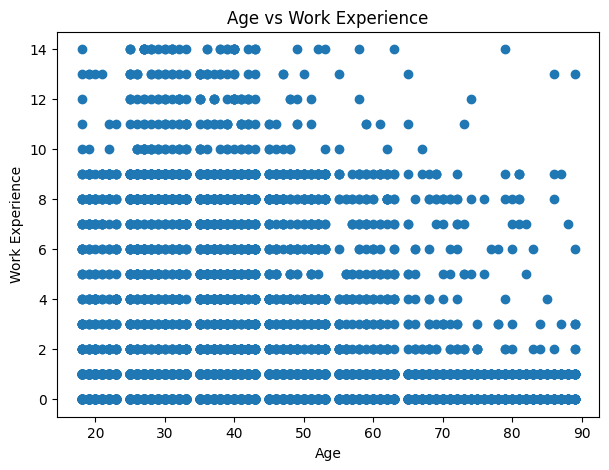

In [30]:
# Plot the relationship between age and work experience
plt.figure(figsize=(7,5))
plt.scatter(df['Age'], df['Work_Experience'])
plt.title('Age vs Work Experience')
plt.xlabel('Age')
plt.ylabel('Work Experience')
plt.show()

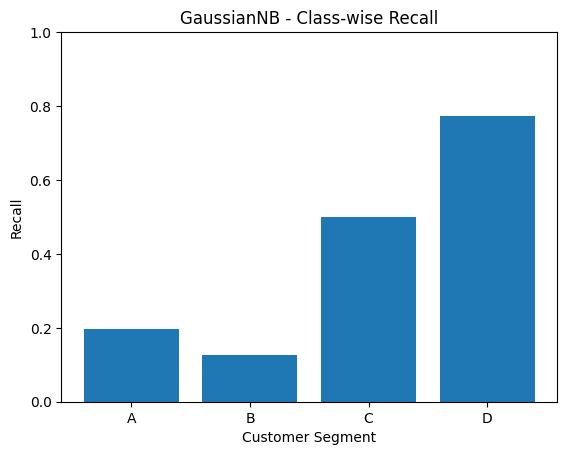

In [32]:
# Plot recall for each customer segment using GaussianNB
from sklearn.metrics import recall_score

classes = sorted(y_test.unique())
recall_values = recall_score(y_test, y_pred_gnb, labels=classes, average=None)

plt.bar(classes, recall_values)
plt.title("GaussianNB - Class-wise Recall")
plt.xlabel("Customer Segment")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.show()

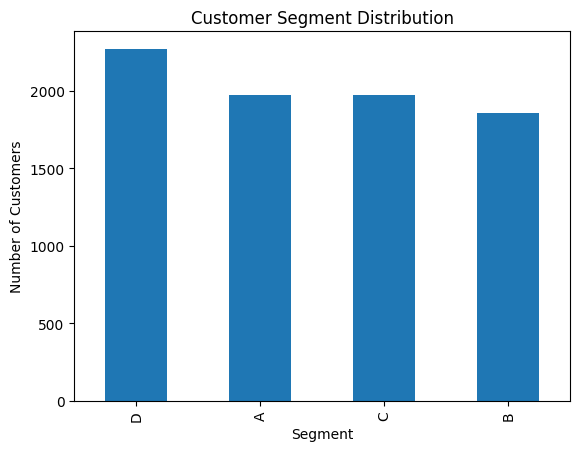

In [33]:
# Plot the distribution of customer segments
import matplotlib.pyplot as plt

df['Segmentation'].value_counts().plot(kind='bar')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

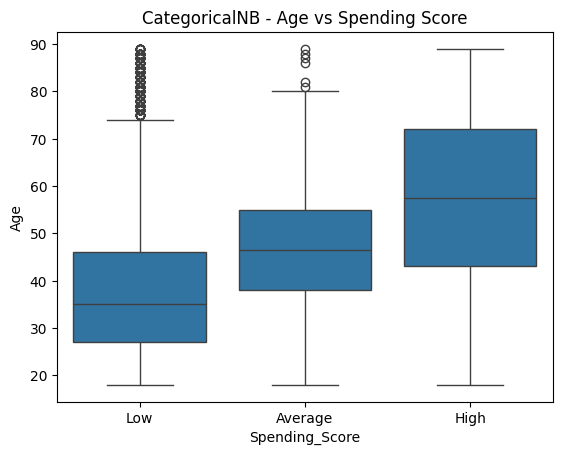

In [34]:
# Plot age distribution across spending-score categories
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Spending_Score', y='Age', data=df)
plt.title('CategoricalNB - Age vs Spending Score')
plt.show()

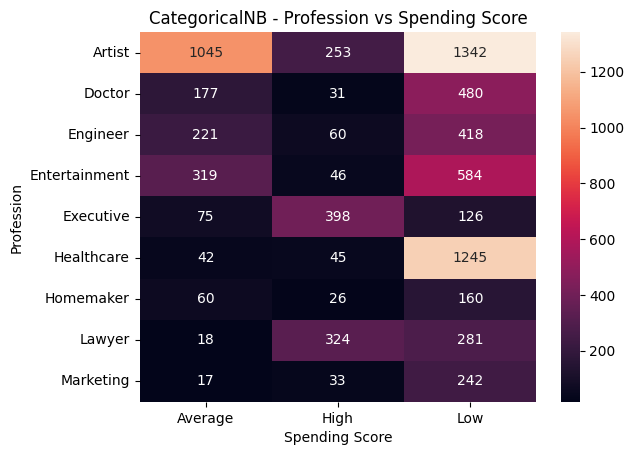

In [35]:
# Plot relationships between categorical features using a heatmap
ct = pd.crosstab(df['Profession'], df['Spending_Score'])

sns.heatmap(ct, annot=True, fmt='d')
plt.title('CategoricalNB - Profession vs Spending Score')
plt.xlabel('Spending Score')
plt.ylabel('Profession')
plt.show()

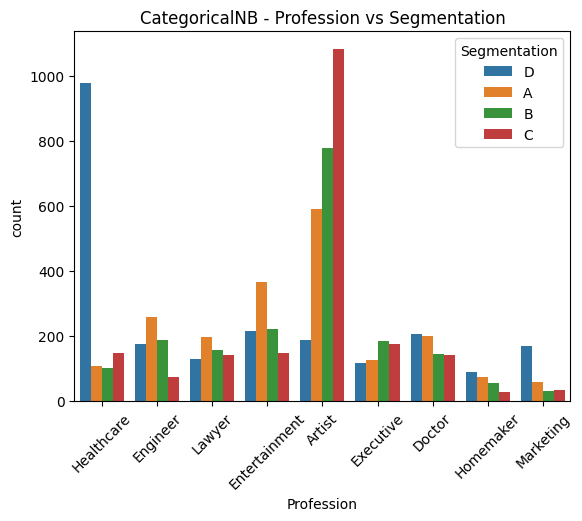

In [36]:
# Plot customer segments across different professions
sns.countplot(x='Profession', hue='Segmentation', data=df)

plt.title('CategoricalNB - Profession vs Segmentation')
plt.xticks(rotation=45)
plt.show()

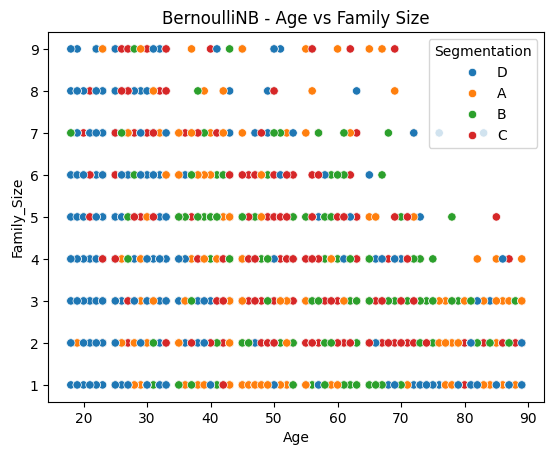

In [37]:
# Plot the relationship between age and family size
sns.scatterplot(x='Age', y='Family_Size', hue='Segmentation', data=df)

plt.title('BernoulliNB - Age vs Family Size')
plt.show()

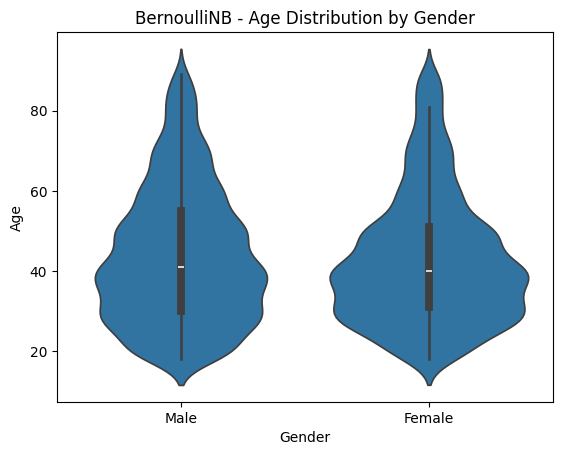

In [38]:
# Plot the age distribution for each gender
sns.violinplot(x='Gender', y='Age', data=df)

plt.title('BernoulliNB - Age Distribution by Gender')
plt.show()

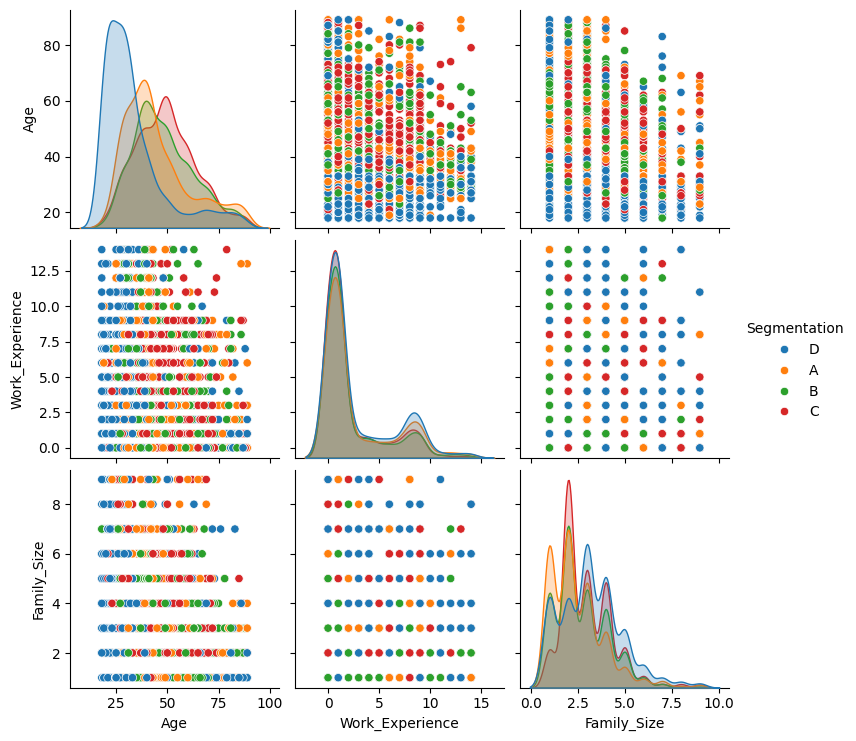

In [39]:
# Plot pairwise relationships among numerical customer features
sns.pairplot(
    df[['Age', 'Work_Experience', 'Family_Size', 'Segmentation']],
    hue='Segmentation'
)

plt.show()

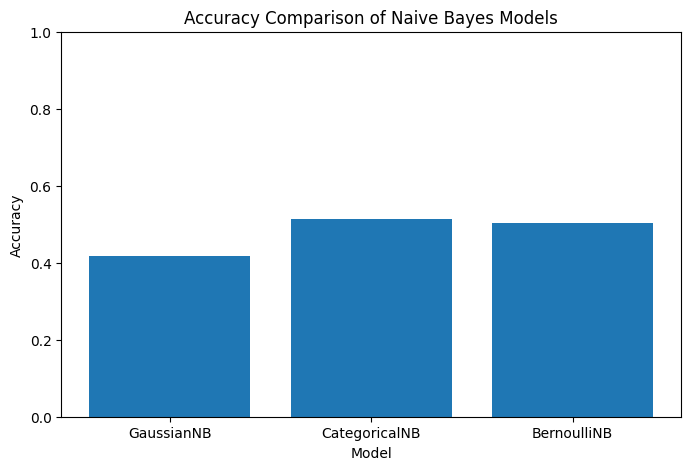

In [40]:
# Compare accuracy of the three Naive Bayes models
models = ['GaussianNB', 'CategoricalNB', 'BernoulliNB']
accuracy = [
    accuracy_score(y_test, y_pred_gnb),
    accuracy_score(y_test, y_pred_cnb),
    accuracy_score(y_test, y_pred_bnb)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy)
plt.title('Accuracy Comparison of Naive Bayes Models')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.show()

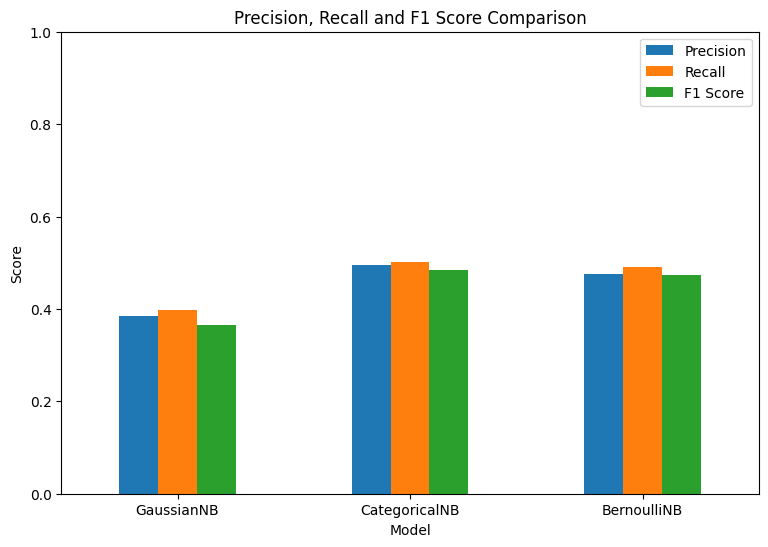

In [41]:
# Compare precision, recall and F1-score across all models
comparison = pd.DataFrame({
    'Model': models,
    'Precision': [
        precision_score(y_test, y_pred_gnb, average='macro'),
        precision_score(y_test, y_pred_cnb, average='macro'),
        precision_score(y_test, y_pred_bnb, average='macro')
    ],
    'Recall': [
        recall_score(y_test, y_pred_gnb, average='macro'),
        recall_score(y_test, y_pred_cnb, average='macro'),
        recall_score(y_test, y_pred_bnb, average='macro')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_gnb, average='macro'),
        f1_score(y_test, y_pred_cnb, average='macro'),
        f1_score(y_test, y_pred_bnb, average='macro')
    ]
})

comparison.set_index('Model').plot(kind='bar', figsize=(9,6))
plt.title('Precision, Recall and F1 Score Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

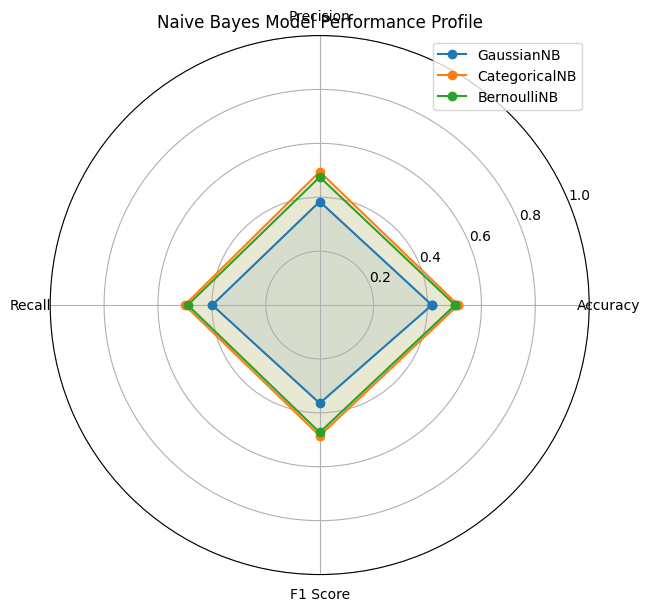

In [42]:
# Compare the overall performance profile of the three models
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for i, model in enumerate(models):
    values = [
        accuracy[i],
        comparison.iloc[i]['Precision'],
        comparison.iloc[i]['Recall'],
        comparison.iloc[i]['F1 Score']
    ]
    values += values[:1]

    ax.plot(angles, values, marker='o', label=model)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0,1)

plt.title('Naive Bayes Model Performance Profile')
plt.legend()
plt.show()

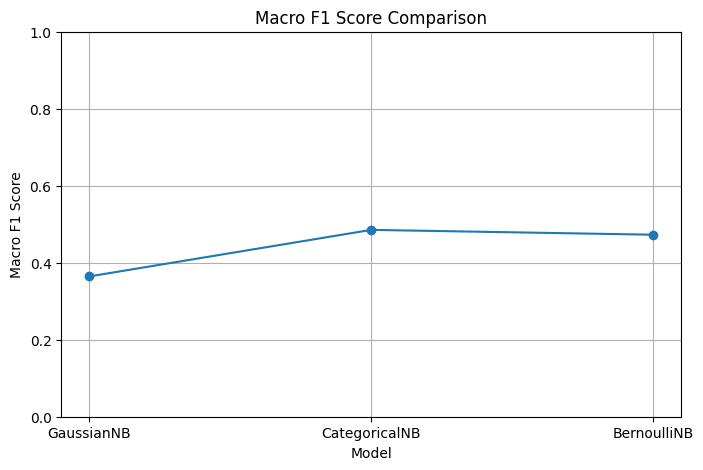

In [43]:
# Compare macro F1-score across the three models
plt.figure(figsize=(8,5))
plt.plot(models, comparison['F1 Score'], marker='o')

plt.title('Macro F1 Score Comparison')
plt.xlabel('Model')
plt.ylabel('Macro F1 Score')
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [44]:
# Identify the best Naive Bayes model based on accuracy
accuracy_scores = {
    'GaussianNB': accuracy_score(y_test, y_pred_gnb),
    'CategoricalNB': accuracy_score(y_test, y_pred_cnb),
    'BernoulliNB': accuracy_score(y_test, y_pred_bnb)
}

best_model = max(accuracy_scores, key=accuracy_scores.get)

print("Accuracy Scores:")
for model, score in accuracy_scores.items():
    print(f"{model}: {score:.4f}")

print("\nBest Model based on Accuracy:", best_model)
print("Best Accuracy:", accuracy_scores[best_model])

Accuracy Scores:
GaussianNB: 0.4164
CategoricalNB: 0.5136
BernoulliNB: 0.5025

Best Model based on Accuracy: CategoricalNB
Best Accuracy: 0.5136307311028501


In [53]:
# Predict the customer segment for a new customer using the selected model

new_customer = pd.DataFrame({
    'Gender': ['Male'],
    'Ever_Married': ['Yes'],
    'Age': [35],
    'Graduated': ['Yes'],
    'Profession': ['Healthcare'],
    'Work_Experience': [5],
    'Spending_Score': ['High'],
    'Family_Size': [3],
    'Var_1': ['Cat_6']
})

print("New Customer:")
display(new_customer)

New Customer:


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
0,Male,Yes,35,Yes,Healthcare,5,High,3,Cat_6


In [54]:
# Install TensorFlow for building the TabTransformer model
!pip install -q tensorflow

In [55]:
# Check the TensorFlow version
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [64]:
# Check whether the existing Dataset 1 data is already numerically encoded
print(X_train.dtypes)
print(X_train.head())

Gender              object
Ever_Married        object
Age                  int64
Graduated           object
Profession          object
Work_Experience    float64
Spending_Score      object
Family_Size        float64
Var_1               object
dtype: object
      Gender Ever_Married  Age Graduated     Profession  Work_Experience  \
917   Female           No   32       Yes         Artist              9.0   
3398    Male          Yes   72       Yes  Entertainment              1.0   
2045  Female           No   33       Yes  Entertainment              1.0   
8060  Female          Yes   48       Yes         Artist              0.0   
4604  Female          Yes   28        No         Doctor              9.0   

     Spending_Score  Family_Size  Var_1  
917             Low          1.0  Cat_6  
3398        Average          2.0  Cat_6  
2045            Low          4.0  Cat_6  
8060        Average          6.0  Cat_6  
4604            Low          1.0  Cat_7  
